# Entregab de Laboratiorio 1

Miembros:
- Joseph Anderson Cose Rojas


## Parte 1


@Josue debe ir colocando tu código aqui

## Parte 2
@Elmer aquí va tu resolución

## Parte 3

### Pregunta 3.2

Se presenta el código a manera de respuesta:

```sql
CREATE OR REPLACE FUNCTION employees.fn_validar_salario()
RETURNS TRIGGER AS $$
BEGIN
    IF NEW.amount < 30000 THEN
        RAISE EXCEPTION 'Salario menor al mínimo permitido';
    END IF;
    RETURN NEW;
END;
$$ LANGUAGE plpgsql;

CREATE TRIGGER trg_validar_salario
BEFORE INSERT ON employees.salary
FOR EACH ROW
EXECUTE FUNCTION employees.fn_validar_salario();
```


### Pregunta 3.3
```sql
CREATE OR REPLACE PROCEDURE employees.sp_ajustar_salario(
    p_employee_id BIGINT,
    p_nuevo_monto BIGINT,
    p_anio INT
)
LANGUAGE plpgsql
AS $$
DECLARE
    v_old_amount BIGINT;
    v_table TEXT;
BEGIN
    -- 1. Obtener salario vigente
    SELECT amount INTO v_old_amount
    FROM employees.salary
    WHERE employee_id = p_employee_id
      AND to_date > CURRENT_DATE; --validación especifica

    -- 2. Cerrar registro de salario vigente (to_date = CURRENT_DATE)
    UPDATE employees.salary
    SET to_date = CURRENT_DATE
    WHERE employee_id = p_employee_id
      AND to_date > CURRENT_DATE;

    -- 3. Insertar nuevo salario (el trigger valida el monto)
    INSERT INTO employees.salary(employee_id, amount, from_date, to_date)
    VALUES (p_employee_id, p_nuevo_monto, CURRENT_DATE, '9999-01-01');

    -- 4. Insertar auditoria, generar dinámicamente el nombre de la tabla según el año
    v_table := 'audit_salary_' || p_anio;

EXECUTE format(
    'INSERT INTO %I.%I (employee_id, old_amount, new_amount) VALUES ($1,$2,$3)',
    'employees', v_table
)
USING p_employee_id, v_old_amount, p_nuevo_monto;

END;
$$;
```


#### Resultado de las pruebas Testing de la función y procedimiento

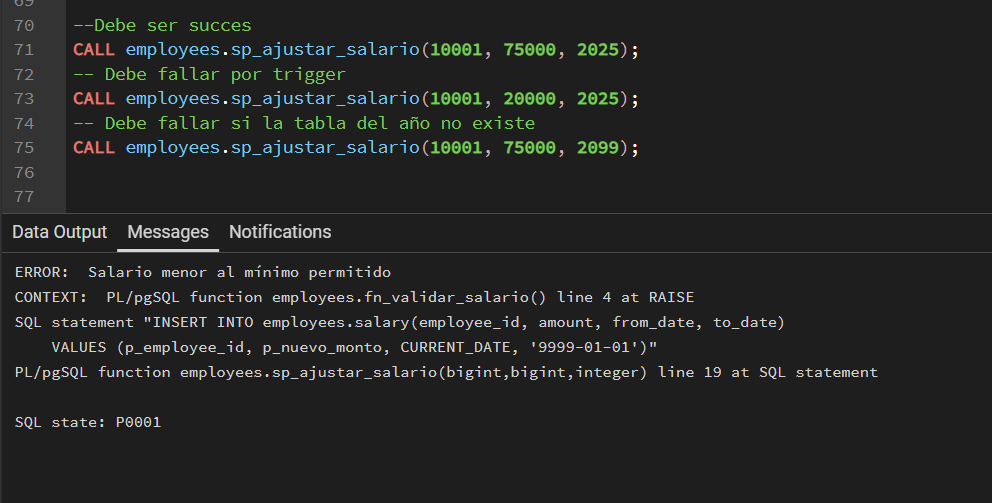
 > Aqui el tercer comando no se ejecutó aún por el error inicial del segundo

 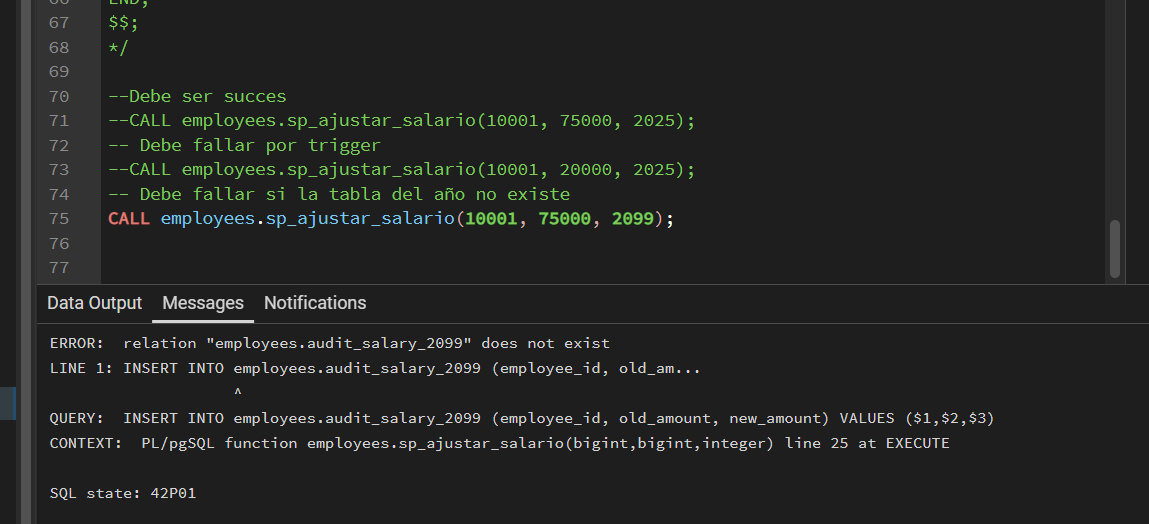
> Aqui el fallo es el esperado de la 3° ejecución


### Preguntas

- 1. Por que estamos trabjando con tablas dinamicas y postgresql para poder hace run insert debe saber el nombre de la tabla en tiempo de compilación, no de ejecución.
- 2. Bueno logicamente va a fallar, específicamente porque hemos establecido un trigger que lo que hace es que en el paso del INSERT previamente valide que el nuevo monto no sea menor a 30000, lo que lanzó el error finalmente
- 3. Bueno se ejecuta el tradicional ROLLBACK si es que falla la operación.